In [5]:
# 1. Load basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# 2. Load dataset (simple dataset)
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url)

In [9]:
# 3. Analyse dataset
print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nStatistics:\n", df.describe())

First 5 rows:
    Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Statistics:
        Unnamed: 0          TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.

In [11]:
# 4. Pre-process the data
# Use only TV advertising for simple linear regression
X = df['TV'].values
y = df['sales'].values

# Normalize data (optional but good practice)
X = (X - X.mean()) / X.std()

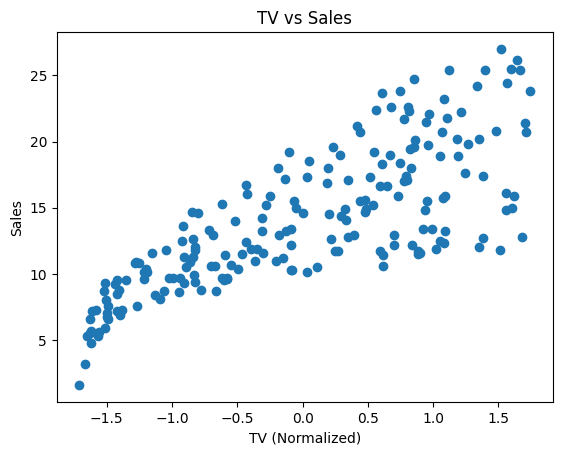

In [12]:
# 5. Visualize the data
plt.scatter(X, y)
plt.title("TV vs Sales")
plt.xlabel("TV (Normalized)")
plt.ylabel("Sales")
plt.show()

In [13]:

# 6. Separate feature and prediction column
X = X.reshape(-1, 1)
m = len(y)

# Add bias term (column of 1s)
X_b = np.c_[np.ones((m, 1)), X]

In [14]:
# 7. Hypothesis Function
def hypothesis(X, theta):
    return np.dot(X, theta)

In [15]:
# 8. Cost Function (Mean Squared Error)
def cost_function(X, y, theta):
    m = len(y)
    return (1/(2*m)) * np.sum((hypothesis(X, theta) - y) ** 2)

In [16]:
# 9. Gradient Descent Algorithm
def gradient_descent(X, y, theta, lr, iterations):
    m = len(y)
    cost_history = []

    for i in range(iterations):
        gradients = (1/m) * np.dot(X.T, (hypothesis(X, theta) - y))
        theta = theta - lr * gradients
        cost_history.append(cost_function(X, y, theta))

    return theta, cost_history

In [17]:
# 10. Train the model
theta = np.zeros(2)  # initial parameters
learning_rate = 0.01
iterations = 1000

theta, cost_history = gradient_descent(X_b, y, theta, learning_rate, iterations)

print("\nBest parameters (theta):", theta)


Best parameters (theta): [     14.022      4.0708]


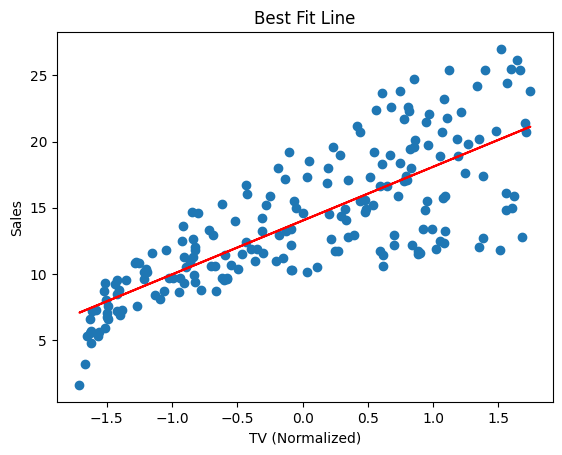

In [18]:

# 11. Best fit line
y_pred = hypothesis(X_b, theta)

plt.scatter(X, y)
plt.plot(X, y_pred, color='red')
plt.title("Best Fit Line")
plt.xlabel("TV (Normalized)")
plt.ylabel("Sales")
plt.show()


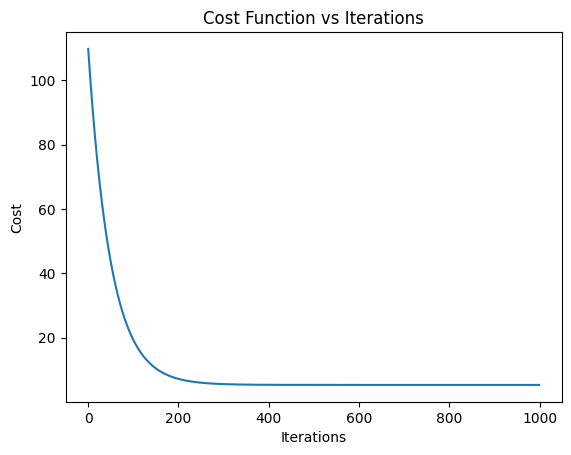

In [19]:

# 12. Cost vs Iterations (Learning Curve)
plt.plot(range(iterations), cost_history)
plt.title("Cost Function vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()